<a href="https://colab.research.google.com/github/Samujjalborah/python-learning-journey/blob/main/Day_14_%E2%80%93_Food_Delivery_Data_Visualization_Portfolio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Day 14 - Food Delivery Data Visualization Portfolio

## Objective

This notebook explores the Food Delivery Business Performance dataset using Matplotlib and Seaborn. Various visualizations are created to identify trends, compare business performance, analyze relationships between variables, and communicate meaningful insights.

**Developed by:** Samujjal Borah

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.figsize"]=(8,5)
df = pd.read_csv("food_delivery_business.csv")

In [2]:
df.head()

,Order_Batch_ID,Date,Month,Day,City,Cuisine,Order_Channel,Weather,Orders,Average_Order_Value,Revenue,Marketing_Spend,Discounts,Avg_Delivery_Minutes,Customer_Rating,Repeat_Customer_Percent
0,FD0001,2025-03-22,March,Saturday,Hyderabad,North Indian,App,Hot,156,421.03,67374.27,28150.42,7859.02,30.7,4.38,45.1
1,FD0002,2025-04-15,April,Tuesday,Chandigarh,Chinese,App,Rainy,129,371.99,50312.93,20907.75,2604.03,38.0,4.34,40.4
2,FD0003,2025-01-26,January,Sunday,Mumbai,Healthy,App,Clear,157,490.16,71929.08,18930.77,3613.92,25.3,4.65,43.0
3,FD0004,2025-06-20,June,Friday,Pune,Chinese,App,Hot,147,391.25,58803.81,35926.51,10092.64,32.6,4.48,41.2
4,FD0005,2025-08-07,August,Thursday,Bengaluru,Fast Food,Partner Platform,Rainy,172,243.76,40416.50,23514.60,2500.30,39.3,4.16,35.9


In [3]:
print("Rows:",df.shape[0])
print("Columns:",df.shape[1])

Rows: 360
Columns: 16


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 360 entries, 0 to 359
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Order_Batch_ID           360 non-null    object 
 1   Date                     360 non-null    object 
 2   Month                    360 non-null    object 
 3   Day                      360 non-null    object 
 4   City                     360 non-null    object 
 5   Cuisine                  360 non-null    object 
 6   Order_Channel            360 non-null    object 
 7   Weather                  360 non-null    object 
 8   Orders                   360 non-null    int64  
 9   Average_Order_Value      360 non-null    float64
 10  Revenue                  360 non-null    float64
 11  Marketing_Spend          360 non-null    float64
 12  Discounts                360 non-null    float64
 13  Avg_Delivery_Minutes     360 non-null    float64
 14  Customer_Rating          3

In [5]:
df.describe()

,Orders,Average_Order_Value,Revenue,Marketing_Spend,Discounts,Avg_Delivery_Minutes,Customer_Rating,Repeat_Customer_Percent
count,360.000000,360.000000,360.000000,360.000000,360.000000,360.000000,360.000000,360.000000
mean,147.647222,409.151083,60591.114778,27161.430028,5753.397000,32.577500,4.452861,41.600000
std,33.387161,70.249186,17387.926132,6970.558278,2647.410844,5.281562,0.209699,5.336472
min,58.000000,243.760000,20618.530000,11336.640000,1219.310000,20.600000,3.810000,24.800000
25%,123.750000,353.840000,48400.832500,21822.500000,3566.615000,28.675000,4.310000,37.900000
50%,147.000000,412.410000,58779.190000,25874.140000,5226.870000,32.000000,4.470000,41.900000
75%,169.000000,464.945000,71740.142500,32387.137500,7610.367500,35.950000,4.610000,45.225000
max,235.000000,575.940000,121381.980000,45000.000000,15000.000000,50.100000,4.940000,54.000000


In [6]:
df.dtypes

,0
Order_Batch_ID,object
Date,object
Month,object
Day,object
City,object
Cuisine,object
Order_Channel,object
Weather,object
Orders,int64
Average_Order_Value,float64


In [7]:
df.isnull().sum()

,0
Order_Batch_ID,0
Date,0
Month,0
Day,0
City,0
Cuisine,0
Order_Channel,0
Weather,0
Orders,0
Average_Order_Value,0


1. Revenue by City

In [8]:
city_summary = (
    df.groupby("City")
      .agg(
          Orders=("Orders", "sum"),
          Revenue=("Revenue", "sum"),
          Avg_Rating=("Customer_Rating", "mean")
      )
      .sort_values("Revenue", ascending=False)
)

city_summary

,Orders,Revenue,Avg_Rating
City,,,
Bengaluru,9394,3851958.65,4.433962
Delhi,9288,3808183.88,4.406415
Hyderabad,7140,2824382.94,4.471667
Mumbai,6633,2730403.79,4.417317
Pune,5812,2406273.63,4.469286
Jaipur,4931,2129246.70,4.484048
Chandigarh,5002,2034416.22,4.492000
Kochi,4953,2027935.51,4.463902


2. Revenue by Cuisine

In [9]:
cuisine_summary = (
    df.groupby("Cuisine")
      .agg(
          Orders=("Orders", "sum"),
          Revenue=("Revenue", "sum"),
          Avg_Rating=("Customer_Rating", "mean")
      )
      .sort_values("Revenue", ascending=False)
)

cuisine_summary

,Orders,Revenue,Avg_Rating
Cuisine,,,
Healthy,10024,4988656.66,4.445441
North Indian,9030,3915404.79,4.497213
Biryani,8141,3760155.52,4.438571
Chinese,9167,3594364.34,4.442063
South Indian,8189,2838647.33,4.453148
Fast Food,8602,2715572.68,4.440172


3. Revenue by Order Channel

In [10]:
channel_summary = (
    df.groupby("Order_Channel")
      .agg(
          Orders=("Orders", "sum"),
          Revenue=("Revenue", "sum"),
          Avg_Rating=("Customer_Rating", "mean")
      )
      .sort_values("Revenue", ascending=False)
)

channel_summary

,Orders,Revenue,Avg_Rating
Order_Channel,,,
App,32335,13435579.94,4.509005
Website,10803,4471108.12,4.366494
Partner Platform,10015,3906113.26,4.380694


4. Correlation coefficients

In [11]:
print("Marketing Spend vs Revenue:",
      round(df["Marketing_Spend"].corr(df["Revenue"]),3))

print("Delivery Time vs Customer Rating:",
      round(df["Avg_Delivery_Minutes"].corr(df["Customer_Rating"]),3))

print("Orders vs Revenue:",
      round(df["Orders"].corr(df["Revenue"]),3))

Marketing Spend vs Revenue: 0.198
Delivery Time vs Customer Rating: -0.876
Orders vs Revenue: 0.76


5. Correlation matrix

In [12]:
corr_matrix = df.select_dtypes(include="number").corr()
corr_matrix

,Orders,Average_Order_Value,Revenue,Marketing_Spend,Discounts,Avg_Delivery_Minutes,Customer_Rating,Repeat_Customer_Percent
Orders,1.000000,-0.010645,0.759617,0.179173,0.403633,0.124756,-0.110504,-0.004926
Average_Order_Value,-0.010645,1.000000,0.579619,0.079387,0.298327,-0.055923,0.016393,0.053220
Revenue,0.759617,0.579619,1.000000,0.198127,0.524685,0.047182,-0.056375,0.030634
Marketing_Spend,0.179173,0.079387,0.198127,1.000000,0.751785,-0.028608,0.051583,0.046916
Discounts,0.403633,0.298327,0.524685,0.751785,1.000000,-0.016603,0.043929,0.088643
Avg_Delivery_Minutes,0.124756,-0.055923,0.047182,-0.028608,-0.016603,1.000000,-0.875881,-0.759633
Customer_Rating,-0.110504,0.016393,-0.056375,0.051583,0.043929,-0.875881,1.000000,0.824341
Repeat_Customer_Percent,-0.004926,0.053220,0.030634,0.046916,0.088643,-0.759633,0.824341,1.000000


Interpretation for Each Visualization

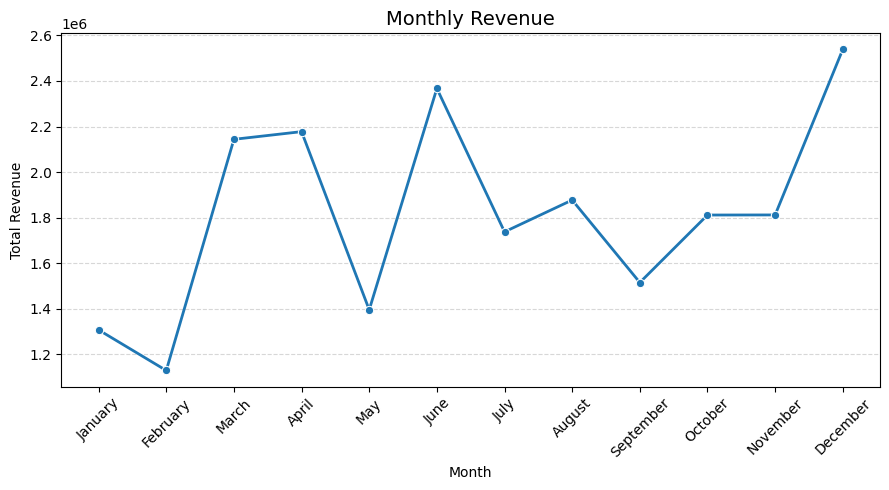

In [26]:
plt.figure(figsize=(9,5))

sns.lineplot(
    data=monthly_revenue,
    x="Month",
    y="Revenue",
    marker="o",
    linewidth=2
)

plt.title("Monthly Revenue", fontsize=14)
plt.xlabel("Month")
plt.ylabel("Total Revenue")

plt.xticks(rotation=45)

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

📈 Line Plot – Revenue Over Months
### Interpretation


Monthly revenue fluctuates throughout the year rather than following a steady upward or downward trend. Revenue is lowest in **February**, increases during **March and April**, reaches another peak in **June**, and records the highest revenue in **December**, suggesting seasonal variations in business performance.


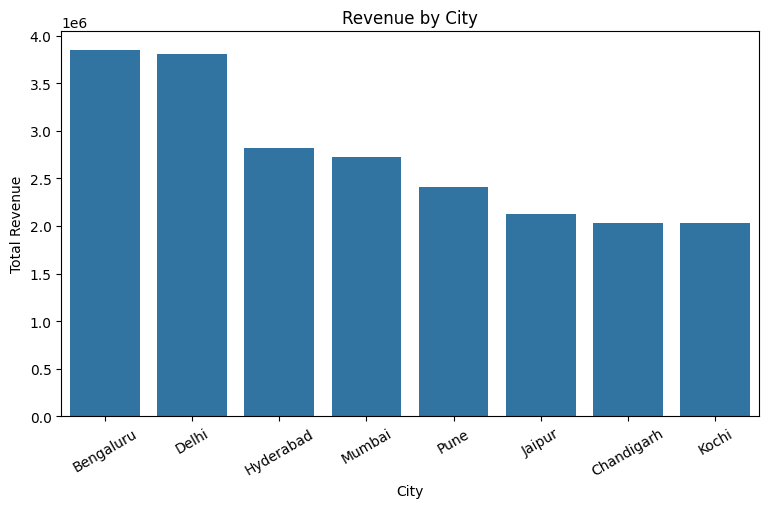

In [24]:
city_revenue = (
    df.groupby("City")["Revenue"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(9,5))

sns.barplot(
    x=city_revenue.index,
    y=city_revenue.values
)

plt.title("Revenue by City")
plt.xlabel("City")
plt.ylabel("Total Revenue")

plt.xticks(rotation=30)

plt.show()

.
📊 Bar Chart – Revenue by City
### Interpretation

Bengaluru generated the highest total revenue, followed closely by Delhi. Chandigarh and Kochi recorded the lowest revenues among the cities included in the dataset.

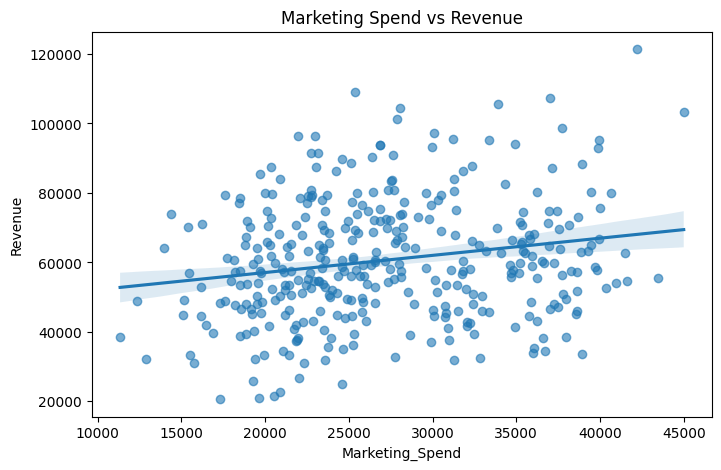

In [15]:
plt.figure(figsize=(8,5))

sns.regplot(
    data=df,
    x="Marketing_Spend",
    y="Revenue",
    scatter_kws={"alpha":0.6}
)

plt.title("Marketing Spend vs Revenue")

plt.show()

🔵 Scatter Plot – Marketing Spend vs Revenue
### Interpretation

The scatter plot shows a weak positive relationship between marketing spend and revenue. Although higher marketing expenditure is associated with slightly higher revenue, the wide spread of points indicates that marketing spend alone does not explain revenue variation.

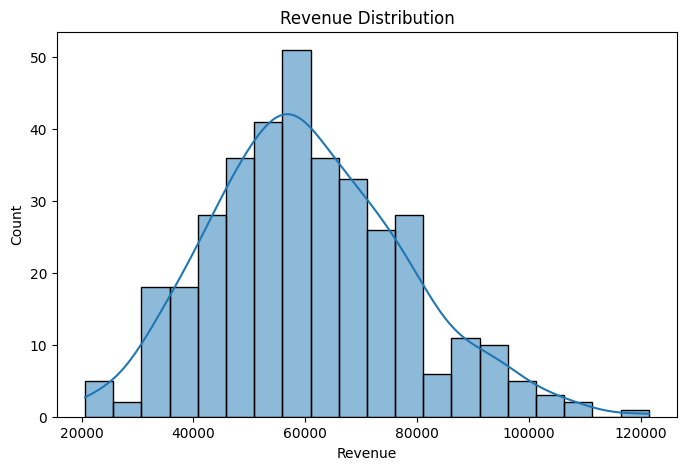

In [16]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Revenue"],
    bins=20,
    kde=True
)

plt.title("Revenue Distribution")
plt.xlabel("Revenue")

plt.show()


📉 Histogram – Revenue Distribution
### Interpretation

Revenue values are concentrated between approximately 45,000 and 70,000, with a slight right-skew caused by a smaller number of high-revenue observations.

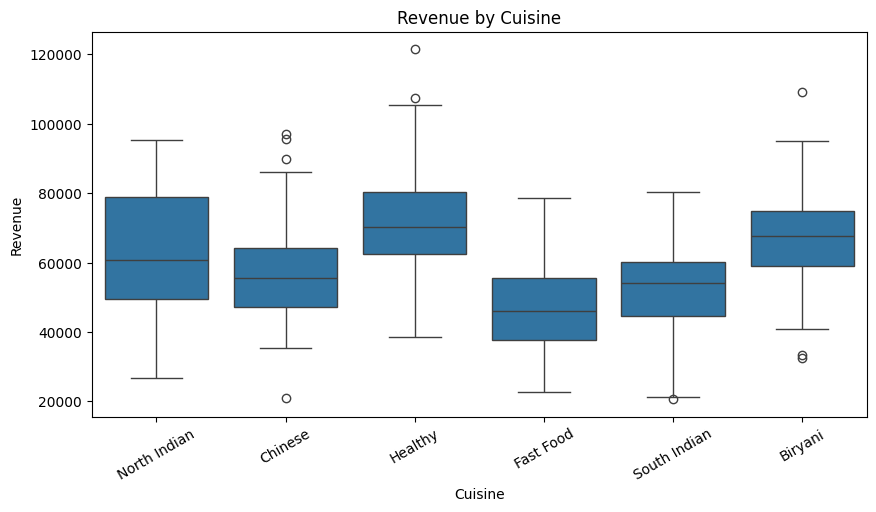

In [17]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=df,
    x="Cuisine",
    y="Revenue"
)

plt.title("Revenue by Cuisine")

plt.xticks(rotation=30)

plt.show()


📦 Box Plot – Revenue by Cuisine
### Interpretation
Revenue varies across cuisines. Healthy cuisine has the highest median revenue and the widest distribution, whereas Fast Food records the lowest median revenue among the cuisine categories.

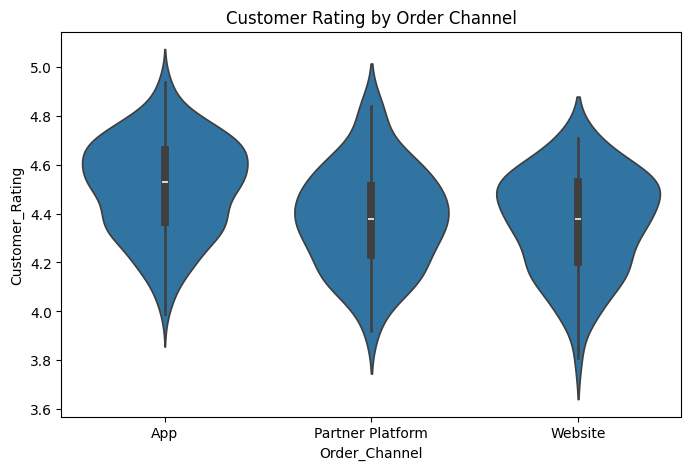

In [18]:
plt.figure(figsize=(8,5))

sns.violinplot(
    data=df,
    x="Order_Channel",
    y="Customer_Rating"
)

plt.title("Customer Rating by Order Channel")

plt.show()

.
🎻 Violin Plot – Customer Rating by Order Channel
### Interpretation

Customer ratings are consistently high across all order channels. Orders placed through the App show a slightly higher concentration of ratings around 4.5–4.7 compared with the other channels.

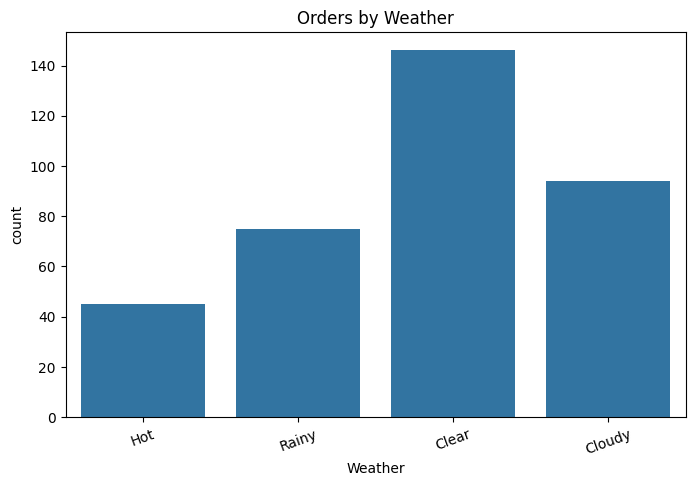

In [19]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Weather"
)

plt.title("Orders by Weather")

plt.xticks(rotation=20)

plt.show()


📊 Count Plot – Weather
### Interpretation

Clear weather was the most frequently observed weather condition during the study period, while Hot weather occurred least frequently.

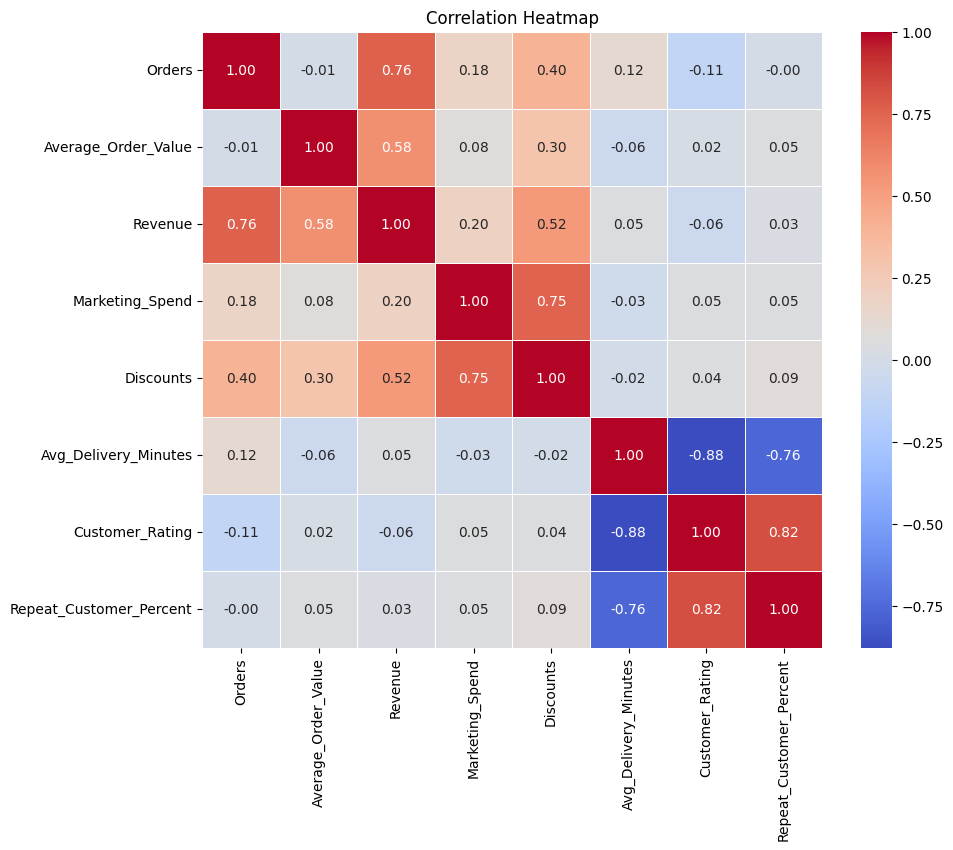

In [20]:
corr_matrix = df.select_dtypes(include="number").corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")

plt.show()


🔥 Correlation Heatmap
### Interpretation

The heatmap reveals a strong positive correlation between Orders and Revenue (0.76). Customer Rating shows a strong negative relationship with Average Delivery Time (-0.88), while Repeat Customer Percentage is strongly positively associated with Customer Rating (0.82).

# Observations

- The dataset contains 360 food delivery records with no missing values.
- Bengaluru generated the highest total revenue, while Chandigarh and Kochi recorded the lowest revenues among the cities.
- Healthy cuisine achieved the highest median and total revenue, whereas Fast Food generated the lowest median revenue.
- Orders placed through the App contributed the highest total revenue and maintained the highest average customer rating.
- Revenue varied throughout the year, with peaks in December and June and a noticeable decline in February.
- Orders and Revenue showed a strong positive correlation (0.76), indicating that increased order volume was associated with higher revenue.
- Average Delivery Time showed a strong negative correlation (-0.88) with Customer Rating, suggesting that longer delivery times were associated with lower customer satisfaction.
- Customer Rating showed a strong positive correlation (0.82) with Repeat Customer Percentage, indicating that satisfied customers were more likely to place repeat orders.

# Conclusion

The Food Delivery Business Performance dataset was explored using a variety of visualizations created with Matplotlib and Seaborn. The analysis identified differences in revenue across cities, cuisines, and order channels while revealing important relationships among operational and business metrics. Orders were strongly associated with revenue, delivery time showed a strong negative association with customer ratings, and repeat customer percentage increased with higher customer satisfaction. Overall, the visualization portfolio provides valuable insights into customer behavior and business performance that can support informed operational and strategic decision-making.